<a href="https://colab.research.google.com/github/amna-chouhdary/American-Sign-Language-ASL-Digits-Recognition-Using-CNN-and-KNN/blob/main/CNN_knn_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

extraction_path = '/content/extracted_archive'

print(f"Contents of {extraction_path}:")
for root, dirs, files in os.walk(extraction_path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Contents of /content/extracted_archive:
/content/extracted_archive/American Sign Language Digits Dataset
/content/extracted_archive/American Sign Language Digits Dataset/9
/content/extracted_archive/American Sign Language Digits Dataset/1
/content/extracted_archive/American Sign Language Digits Dataset/7
/content/extracted_archive/American Sign Language Digits Dataset/5
/content/extracted_archive/American Sign Language Digits Dataset/3
/content/extracted_archive/American Sign Language Digits Dataset/0
/content/extracted_archive/American Sign Language Digits Dataset/8
/content/extracted_archive/American Sign Language Digits Dataset/4
/content/extracted_archive/American Sign Language Digits Dataset/6
/content/extracted_archive/American Sign Language Digits Dataset/2
/content/extracted_archive/American Sign Language Digits Dataset/9/Output Images - Sign 9.csv
/content/extracted_archive/American Sign Language Digits Dataset/9/Input Images - Sign 9
/content/extracted_archive/American Sign L

In [ ]:
import zipfile
import os

archive_path = '/content/archive.zip' # Assuming the uploaded file is named archive.zip
extraction_path = '/content/extracted_archive'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

try:
    with zipfile.ZipFile(archive_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f'Archive extracted to: {extraction_path}')
except zipfile.BadZipFile:
    print(f'Error: {archive_path} is not a valid zip file. Please ensure you uploaded a valid .zip archive.')
except FileNotFoundError:
    print(f'Error: The file {archive_path} was not found. Please ensure the archive was uploaded correctly.')
except Exception as e:
    print(f'An unexpected error occurred: {e}')

Archive extracted to: /content/extracted_archive


Found 5000 image files.
Displaying 1 sample image(s) for each digit:


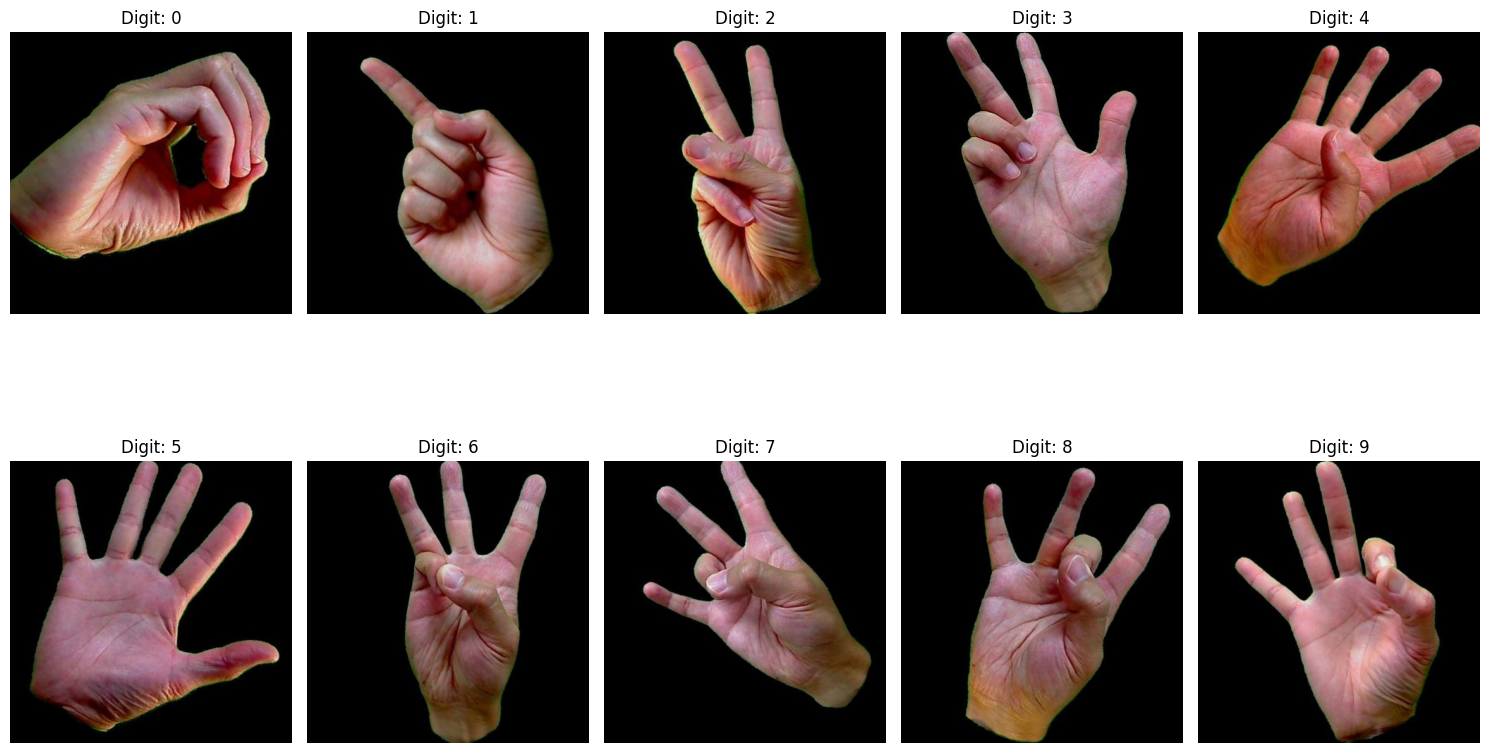

In [ ]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt

image_base_path = '/content/extracted_archive/American Sign Language Digits Dataset'

# Find all JPEG image files recursively
image_files = glob.glob(os.path.join(image_base_path, '**', '*.jpeg'), recursive=True)

print(f"Found {len(image_files)} image files.")

# Group images by digit
digit_image_paths = {str(i): [] for i in range(10)}
for img_path in image_files:
    label = os.path.basename(os.path.dirname(os.path.dirname(img_path)))
    if label.isdigit() and label in digit_image_paths:
        digit_image_paths[label].append(img_path)

# Display a few sample images for each digit category
num_samples_per_digit = 1 # Display one image per digit

plt.figure(figsize=(15, 10))
plot_index = 1

print(f"Displaying {num_samples_per_digit} sample image(s) for each digit:")
for digit in sorted(digit_image_paths.keys()):
    if digit_image_paths[digit]:
        # Take up to num_samples_per_digit images
        for i, img_path in enumerate(digit_image_paths[digit][:num_samples_per_digit]):
            try:
                img = Image.open(img_path)
                ax = plt.subplot(2, 5, plot_index) # Create a 2x5 grid for 10 digits
                ax.imshow(img)
                ax.set_title(f'Digit: {digit}')
                ax.axis('off')
                plot_index += 1
            except Exception as e:
                print(f"Could not load image {img_path}: {e}")
    else:
        print(f"No images found for digit {digit}")

plt.tight_layout()
plt.show()

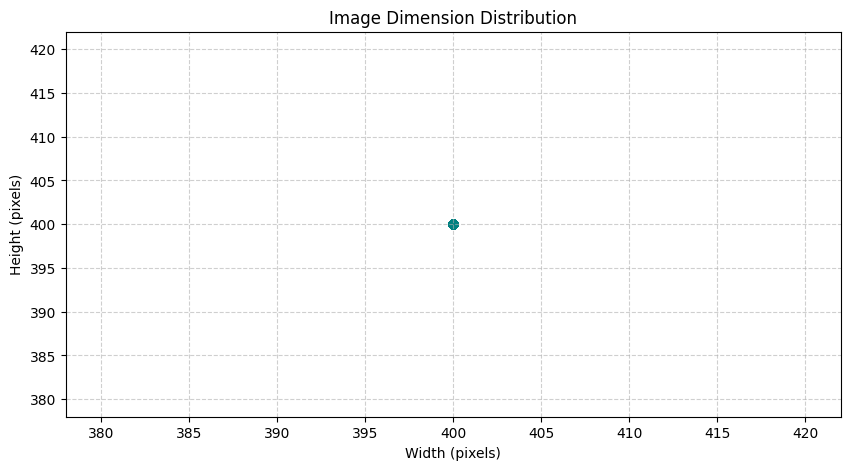

Average Width: 400.00
Average Height: 400.00


In [ ]:
import pandas as pd

# Create a DataFrame from the image paths and labels
image_data = []
for digit, paths in digit_image_paths.items():
    for path in paths:
        image_data.append({'path': path, 'label': digit})

df = pd.DataFrame(image_data)

# Sample 500 images to check dimensions (checking all might be slow)
sample_size = min(500, len(df))
df_sample = df.sample(sample_size, random_state=42) # Added random_state for reproducibility

widths, heights = [], []
for path in df_sample['path']:
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception as e:
        print(f"Could not open image {path}: {e}")

plt.figure(figsize=(10, 5))
plt.scatter(widths, heights, alpha=0.5, color='teal')
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.title('Image Dimension Distribution')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

if sample_size > 0:
    print(f"Average Width: {sum(widths)/sample_size:.2f}")
    print(f"Average Height: {sum(heights)/sample_size:.2f}")
else:
    print("No images were sampled to calculate average dimensions.")

Displaying 9 resized samples for each of the 10 categories...


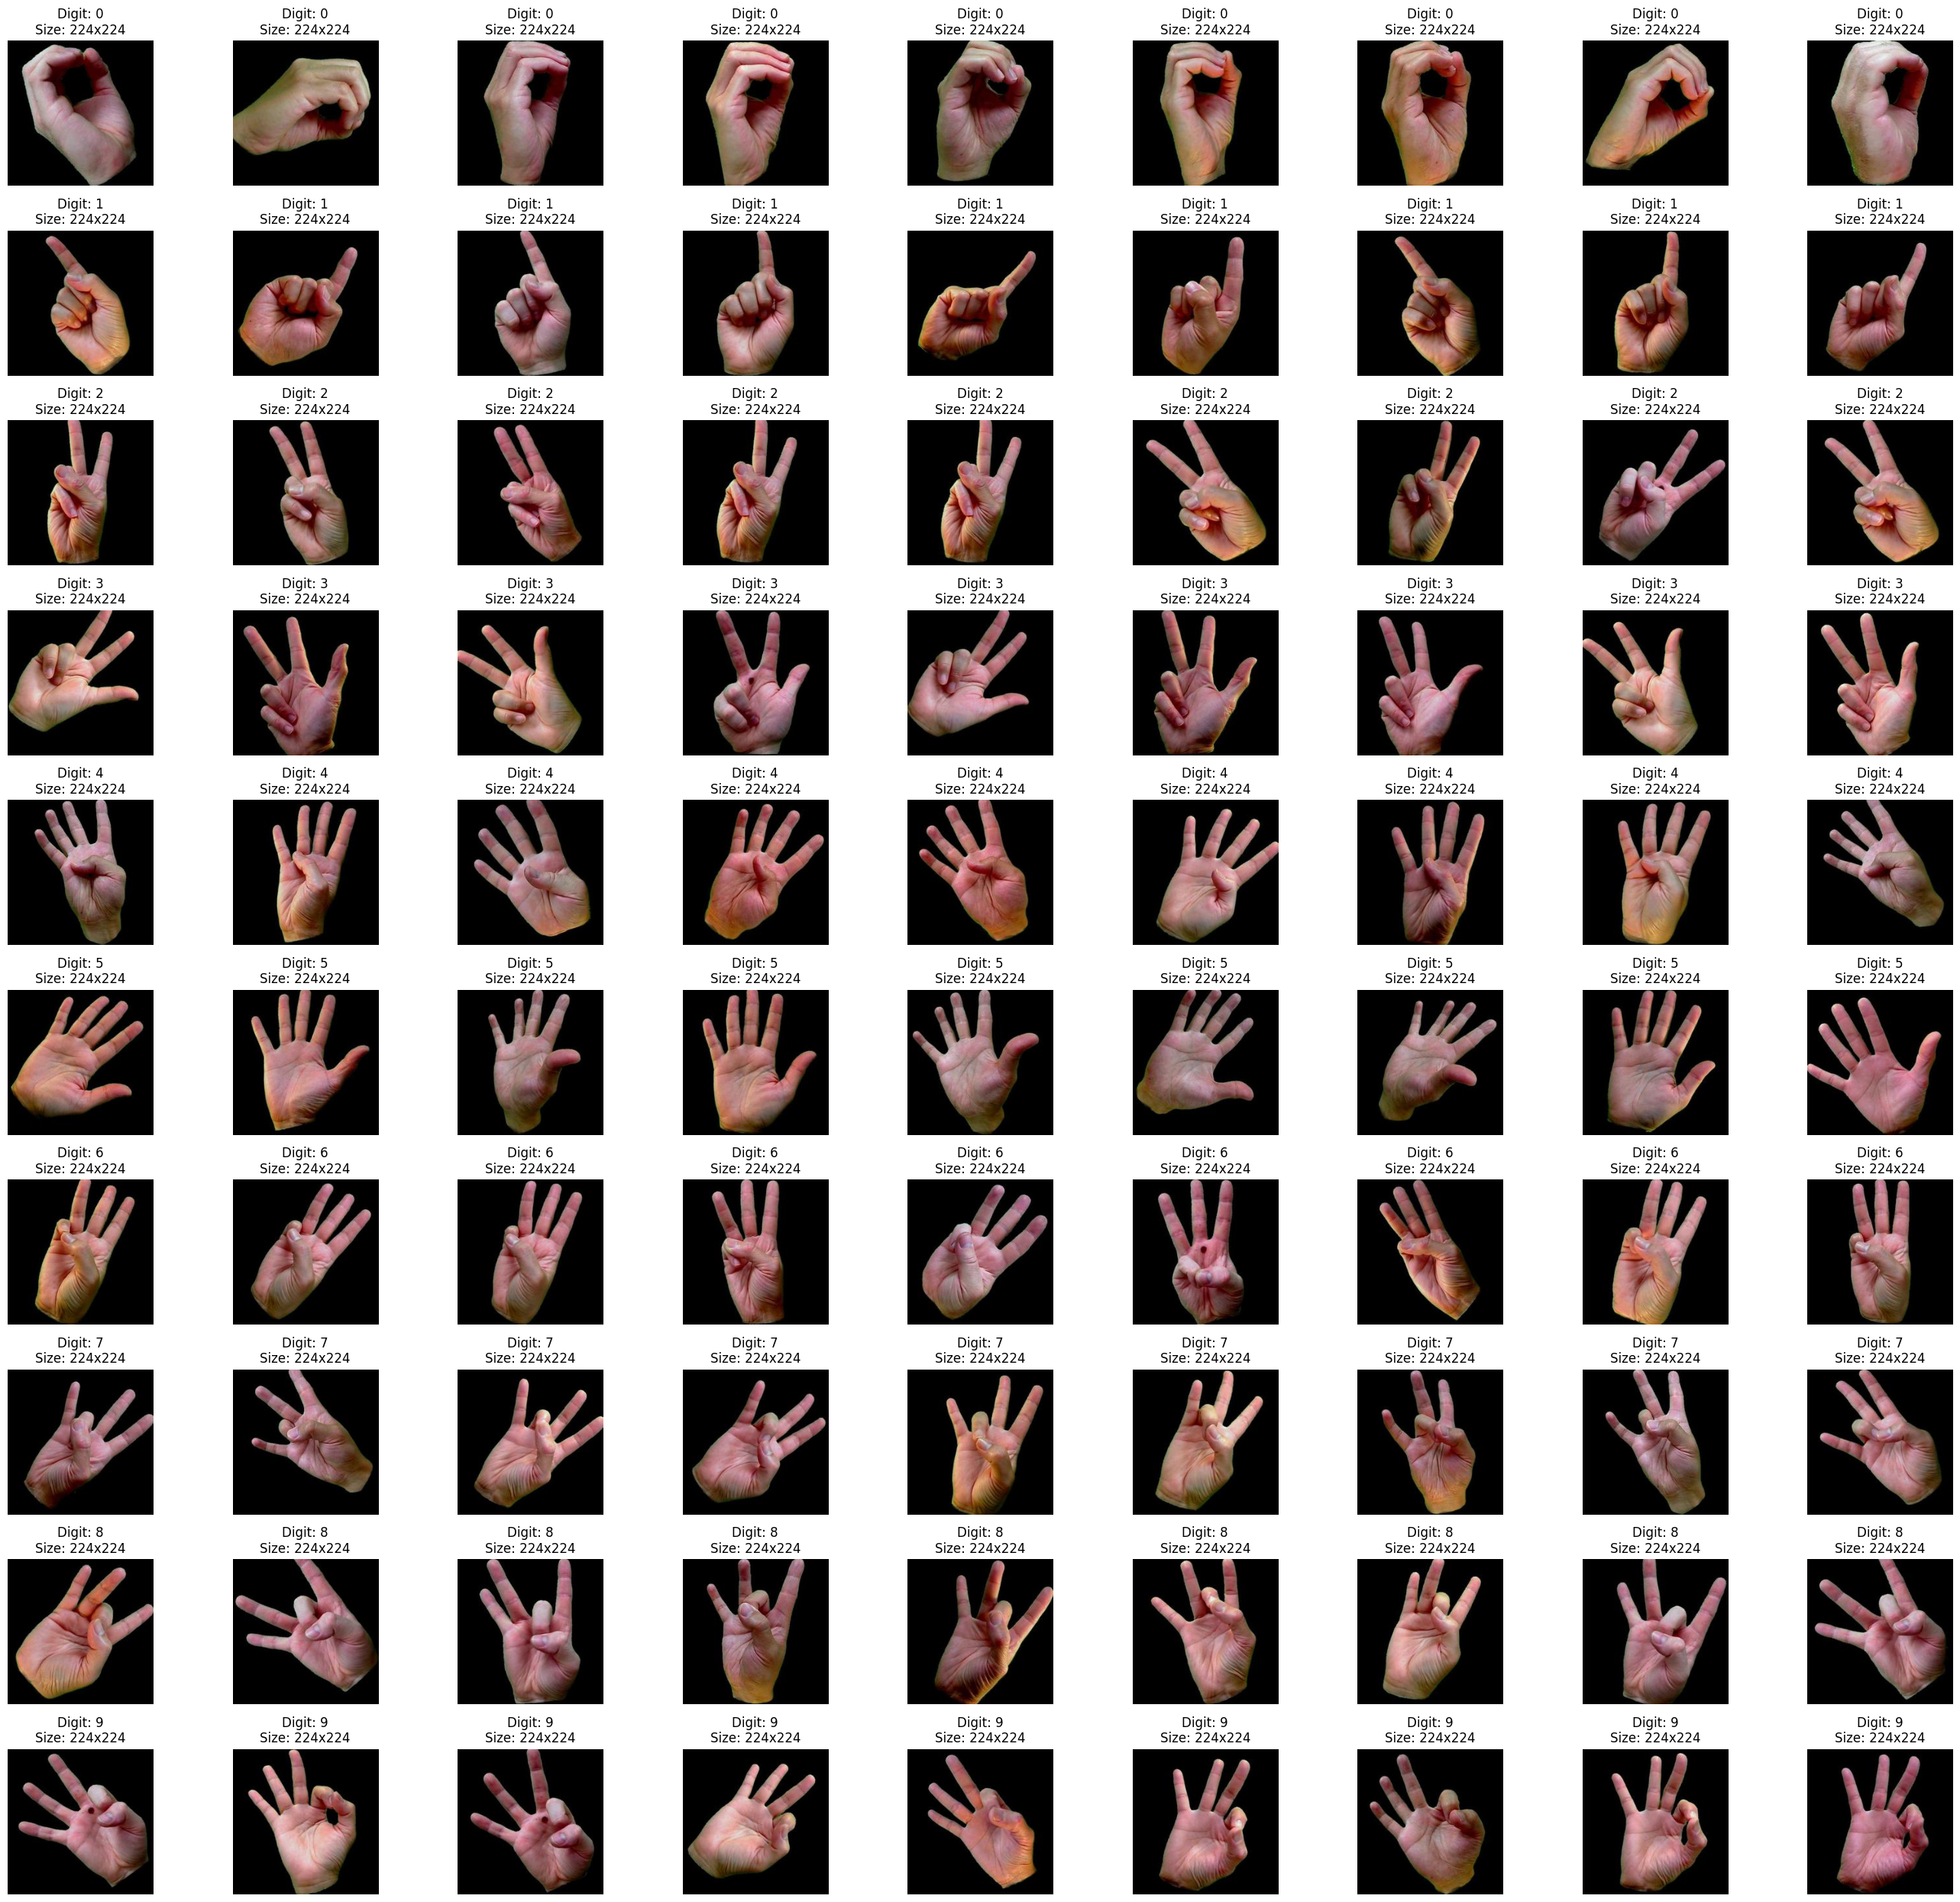

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

# Path to your NEW resized images
processed_path = '/content/processed_asl_digits'
categories = [str(i) for i in range(10)] # Digits 0 through 9

def display_resized_samples(base_path, categories, num_per_class=3):
    # Adjust figsize dynamically based on number of categories and samples
    fig, axes = plt.subplots(len(categories), num_per_class, figsize=(num_per_class * 3, len(categories) * 2.5))

    # Ensure axes is always a 2D array, even for a single row or column
    if len(categories) == 1:
        axes = [axes]
    if num_per_class == 1:
        axes = [[ax] for ax in axes] # Make it a list of lists if num_per_class is 1

    print(f"Displaying {num_per_class} resized samples for each of the {len(categories)} categories...")

    for i, category in enumerate(categories):
        category_folder = os.path.join(base_path, category)
        if not os.path.exists(category_folder):
            print(f"Category folder not found: {category_folder}")
            continue

        all_imgs = [f for f in os.listdir(category_folder) if f.lower().endswith(('.jpeg', '.jpg', '.png'))]

        if not all_imgs:
            print(f"No images found in category: {category_folder}")
            continue

        # Pick random samples, ensuring not to pick more than available
        num_to_sample = min(num_per_class, len(all_imgs))
        samples = random.sample(all_imgs, num_to_sample)

        for j, img_name in enumerate(samples):
            img_path = os.path.join(category_folder, img_name)
            try:
                with Image.open(img_path) as img:
                    # Show image and its new dimensions in the title
                    axes[i, j].imshow(img)
                    axes[i, j].set_title(f"Digit: {category}\nSize: {img.size[0]}x{img.size[1]}")
                    axes[i, j].axis('off')
            except Exception as e:
                print(f"Could not load or display image {img_path}: {e}")

        # Turn off remaining empty subplots in the row if num_to_sample < num_per_class
        for j_fill in range(num_to_sample, num_per_class):
            axes[i, j_fill].axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to display samples
display_resized_samples(processed_path, categories, num_per_class=9)

In [ ]:
import os
from PIL import Image

# Configuration for your ASL Digits Dataset
input_root = '/content/extracted_archive/American Sign Language Digits Dataset'
output_root = '/content/processed_asl_digits'
target_size = (224, 224) # Common size for many deep learning models
categories = [str(i) for i in range(10)] # Digits 0 through 9

# Create output root directory if it doesn't exist
if not os.path.exists(output_root):
    os.makedirs(output_root)
    print(f"Created output directory: {output_root}")

print("Starting image processing...")

for category in categories:
    # Construct the path to the actual image subfolder for each digit
    input_folder = os.path.join(input_root, category, f'Input Images - Sign {category}')
    output_folder = os.path.join(output_root, category)

    # Create output subfolder for the current category
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    print(f"Processing images for digit: {category}")

    # Check if the input folder exists and contains files
    if os.path.exists(input_folder):
        for img_name in os.listdir(input_folder):
            # Only process image files (e.g., .jpeg, .jpg)
            if img_name.lower().endswith(('.jpeg', '.jpg')):
                try:
                    img_path = os.path.join(input_folder, img_name)
                    with Image.open(img_path) as img:
                        # Convert to RGB (handles PNGs with transparency or Grayscale)
                        img = img.convert('RGB')

                        # Resize image
                        resized_img = img.resize(target_size, Image.Resampling.LANCZOS)

                        # Save to new location
                        resized_img.save(os.path.join(output_folder, img_name))
                except Exception as e:
                    print(f"Skipping {img_name} in category {category}: {e}")
            # else: # Optional: print a message for non-image files if desired
            #     print(f"Skipping non-image file {img_name} in category {category}")
    else:
        print(f"Input folder not found for digit {category}: {input_folder}")

print("Done! All images resized and saved to:", output_root)


Starting image processing...
Processing images for digit: 0
Processing images for digit: 1
Processing images for digit: 2
Processing images for digit: 3
Processing images for digit: 4
Processing images for digit: 5
Processing images for digit: 6
Processing images for digit: 7
Processing images for digit: 8
Processing images for digit: 9
Done! All images resized and saved to: /content/processed_asl_digits


In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration
data_path = '/content/processed_asl_digits'
categories = [str(i) for i in range(10)] # Digits 0 through 9
img_size = (64, 64) # Reducing size for KNN to save memory and speed up calculation

X = []
y = []

print("Loading and flattening images...")

for idx, category in enumerate(categories):
    folder_path = os.path.join(data_path, category)
    if not os.path.exists(folder_path):
        print(f"Warning: Category folder not found: {folder_path}. Skipping.")
        continue

    for img_name in os.listdir(folder_path):
        try:
            img_path = os.path.join(folder_path, img_name)
            img = Image.open(img_path).convert('RGB')
            # Resizing smaller specifically for KNN performance
            img = img.resize(img_size)
            img_array = np.array(img).flatten() # Turn 64x64x3 into 12,288 features
            X.append(img_array)
            y.append(idx)
        except Exception as e:
            print(f"Skipping image {img_name} due to error: {e}")
            continue

X = np.array(X)
y = np.array(y)

# Normalize pixel values (0-255 to 0-1)
X = X / 255.0

# Split the data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Total samples loaded: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Loading and flattening images...
Total samples loaded: 5000
Training samples: 4000
Testing samples: 1000



--- Model Evaluation ---
Accuracy: 95.60%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       0.99      1.00      1.00       100
           2       0.96      0.97      0.97       100
           3       0.99      0.98      0.98       100
           4       0.84      0.86      0.85       100
           5       0.98      0.98      0.98       100
           6       0.95      0.94      0.94       100
           7       0.87      0.89      0.88       100
           8       0.98      0.96      0.97       100
           9       1.00      0.98      0.99       100

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



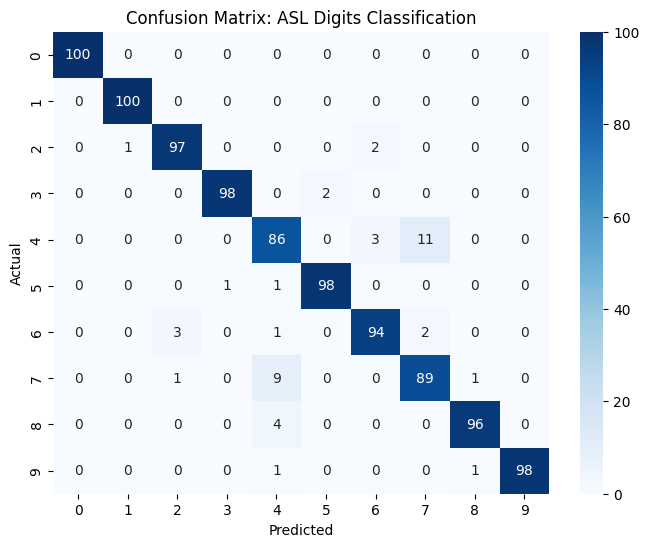

In [ ]:
# Initialize and train KNN
# n_neighbors is the 'K' in KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Results
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=categories))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: ASL Digits Classification')
plt.show()

## Applying a Convolutional Neural Network (CNN) Model

Now, let's apply a Convolutional Neural Network (CNN) model to the dataset. We'll start by importing the necessary libraries, preparing the data specifically for the CNN, defining the model architecture, training it, and finally evaluating its performance with a confusion matrix.

In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix # Added this import
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading and Preprocessing for CNN

We need to load the images again and preprocess them to a `(128, 128)` size and normalize pixel values for the CNN. Labels will be one-hot encoded.

In [ ]:
dataset_path = "/content/processed_asl_digits"   # folder containing 0–9 folders

img_size = 128 # Matching the previously established target size for the CNN

X_cnn = []
y_cnn = []

print(f"Loading and preprocessing images for CNN (resizing to {img_size}x{img_size})...")

for label in range(10):   # Iterate through 0 to 9 folders
    folder_path = os.path.join(dataset_path, str(label))
    if not os.path.exists(folder_path):
        print(f"Warning: Category folder not found: {folder_path}. Skipping.")
        continue

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize((img_size, img_size))
            img = np.array(img) / 255.0   # Normalize pixel values to [0, 1]

            X_cnn.append(img)
            y_cnn.append(label)

        except Exception as e:
            print(f"Skipping image {img_name} due to error: {e}")
            continue

X_cnn = np.array(X_cnn)
y_cnn = np.array(y_cnn)

print(f"Total images loaded for CNN: {len(X_cnn)}")

Loading and preprocessing images for CNN (resizing to 128x128)...
Total images loaded for CNN: 5000


In [ ]:
# One-hot encode the labels
y_cnn = to_categorical(y_cnn, num_classes=10)
print("Labels one-hot encoded.")

Labels one-hot encoded.


In [ ]:
# Split the data into training and testing sets
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_cnn, test_size=0.2, random_state=42, stratify=y_cnn
)

print(f"CNN Training samples: {len(X_train_cnn)}")
print(f"CNN Testing samples: {len(X_test_cnn)}")

CNN Training samples: 4000
CNN Testing samples: 1000


### Defining the CNN Model Architecture

We'll define a simple sequential CNN model with convolutional, pooling, flatten, and dense layers.

In [ ]:
model = Sequential()

# Conv Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)))
model.add(MaxPooling2D(2,2))

# Conv Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Conv Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten layer to transition from convolutional to dense layers
model.add(Flatten())

# Dense Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5)) # Dropout for regularization

# Output Layer with 10 classes (digits 0-9) and softmax activation for probabilities
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Compile and Train the CNN Model

Now, we compile the model with an optimizer, loss function, and metrics, and then train it.

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print("Training the CNN model...")
history = model.fit(
    X_train_cnn, y_train_cnn,
    epochs=10, # You can adjust the number of epochs
    batch_size=32,
    validation_data=(X_test_cnn, y_test_cnn)
)
print("CNN Model training complete.")

Training the CNN model...
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.7097 - loss: 0.8553 - val_accuracy: 0.9630 - val_loss: 0.1193
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.9383 - loss: 0.1931 - val_accuracy: 0.9810 - val_loss: 0.0620
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.9670 - loss: 0.0957 - val_accuracy: 0.9880 - val_loss: 0.0364
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9653 - loss: 0.0936 - val_accuracy: 0.9900 - val_loss: 0.0378
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9803 - loss: 0.0644 - val_accuracy: 0.9930 - val_loss: 0.0256
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.9810 - loss: 0.0544 - val_accuracy: 0.9910 - val_loss: 0.0347
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9795 - loss: 0.0533 - val_accuracy: 0.9940 - val_loss: 0.0299
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9845

### Evaluate CNN Model Performance and Confusion Matrix

Finally, we evaluate the trained CNN model and visualize its performance using a confusion matrix.

CNN Model Test Loss: 0.0357
CNN Model Test Accuracy: 99.20%
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 299ms/step


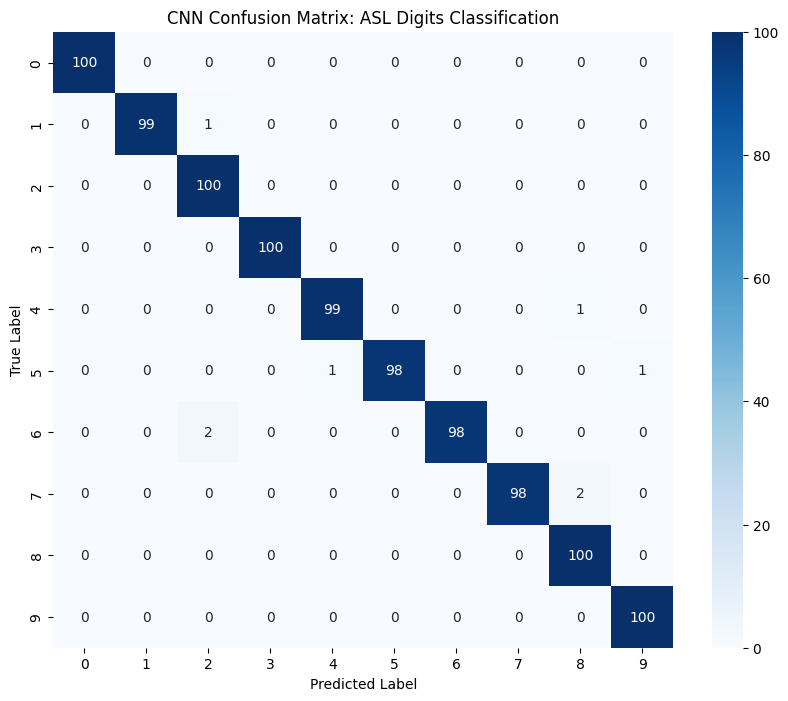

In [ ]:
loss, accuracy = model.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"CNN Model Test Loss: {loss:.4f}")
print(f"CNN Model Test Accuracy: {accuracy*100:.2f}%")

# Generate predictions for the confusion matrix
y_pred_cnn = model.predict(X_test_cnn)
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)
y_true_classes_cnn = np.argmax(y_test_cnn, axis=1)

# Plot Confusion Matrix
cm_cnn = confusion_matrix(y_true_classes_cnn, y_pred_classes_cnn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNN Confusion Matrix: ASL Digits Classification')
plt.show()